# Bayesian Optimisation for Molecular Design

## Learning Objectives

- Understand the molecular optimisation problem and why it requires sample-efficient methods
- Derive and implement Expected Improvement, Upper Confidence Bound, and Probability of Improvement acquisition functions
- Build a complete Bayesian optimisation loop from scratch using GPs
- Apply BO to a realistic molecular property optimisation task
- Understand the exploration--exploitation tradeoff in the context of chemical space

## Prerequisites

- **Module 11, Notebook 03:** Gaussian Processes (GP regression, kernels, posterior predictive)
- **Notebook 01 of this module:** QSAR (molecular descriptors, property prediction)
- **Modules 07--08:** Bayesian inference framework

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q scikit-learn")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel, Matern

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
    GOLD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. The Molecular Optimisation Problem

### 1.1 Why molecular design is hard

The central challenge in computational chemistry and drug discovery is deceptively simple to state:

> **Find a molecule with the best possible value of some target property** (binding affinity, solubility, synthetic accessibility, selectivity, etc.).

Formally, we seek

$$
x^* = \arg\max_{x \in \mathcal{X}} \; f(x),
$$

where:
- $x \in \mathbb{R}^d$ is a **molecular descriptor vector** (e.g., LogP, molecular weight, topological polar surface area, fingerprint bits, or latent-space coordinates from a variational autoencoder),
- $f : \mathbb{R}^d \to \mathbb{R}$ is the **objective function** mapping descriptors to the property of interest,
- $\mathcal{X}$ is the **feasible set** of candidate molecules.

This problem is hard for several interconnected reasons:

1. **Vast chemical space.** The number of synthetically feasible drug-like molecules is estimated at $10^{33}$--$10^{60}$ (Bohacek et al., 1996; Polishchuk et al., 2013). Exhaustive enumeration is out of the question.

2. **Expensive evaluations.** Each query of $f$ corresponds to a real-world experiment — synthesising a compound and measuring its activity in an assay — which may take days to weeks and cost thousands of dollars. Even computational surrogates (DFT calculations, molecular dynamics, docking simulations) can take hours per molecule.

3. **Black-box objective.** We typically have no closed-form expression for $f$. We cannot compute gradients. We can only observe noisy point evaluations $y_i = f(x_i) + \varepsilon_i$.

4. **Multi-modal landscape.** The property surface over chemical space is highly non-convex, with many local optima and complex dependencies between structural features.

### 1.2 The case for sample-efficient optimisation

Given the expense of each evaluation, we need an optimisation strategy that is **sample-efficient**: it should find near-optimal solutions using as few evaluations of $f$ as possible. This immediately rules out:

- **Grid search:** exponential in dimension; wastes evaluations on uninformative regions.
- **Random search:** no learning between iterations; converges slowly.
- **Gradient-based methods:** require differentiable $f$; not available here.
- **Evolutionary algorithms:** effective but typically require thousands of evaluations.

**Bayesian optimisation (BO)** is designed precisely for this regime: expensive, black-box, derivative-free optimisation with a limited evaluation budget (typically 10--500 evaluations). It achieves sample efficiency by maintaining a **probabilistic model** of the objective and using it to make *intelligent* decisions about where to evaluate next.

### 1.3 Concrete example: lead optimisation

In drug discovery, **lead optimisation** is the stage where a promising "hit" compound (identified from high-throughput screening) is systematically modified to improve its properties. Starting from a lead compound with moderate binding affinity ($\text{IC}_{50} \approx 1\,\mu\text{M}$), the medicinal chemist makes structural modifications — adding a methyl group here, replacing a ring there — and tests each variant.

The goal is to simultaneously:
- **Maximise** binding affinity (potency)
- **Maintain** metabolic stability (ADME properties)
- **Minimise** toxicity
- Stay within drug-like property ranges (Lipinski's Rule of Five)

Each design--make--test--analyse (DMTA) cycle takes 4--6 weeks. A typical lead optimisation campaign involves 20--50 such cycles. Any method that can reduce the number of compounds that need to be synthesised translates directly into months of saved time and millions of dollars in reduced costs.

This is where Bayesian optimisation enters the picture.

---

## 2. The Bayesian Optimisation Framework

### 2.1 Two key components

Bayesian optimisation rests on two pillars:

1. **A surrogate model** — a probabilistic model that approximates the expensive objective $f$ and, crucially, quantifies its own uncertainty. We use a **Gaussian process (GP)**, as developed in Module 11, Notebook 03 (Gaussian Processes).

2. **An acquisition function** — a cheap-to-evaluate function $\alpha(x)$ that uses the surrogate's predictions to determine the most promising location for the next evaluation. It encodes our strategy for balancing **exploration** (evaluating in regions of high uncertainty) and **exploitation** (evaluating in regions where the predicted value is high).

### 2.2 The GP surrogate

Recall from Module 11, Notebook 03 that given observations $\mathcal{D}_n = \{(x_i, y_i)\}_{i=1}^n$, a GP posterior yields:

$$
f(x) \mid \mathcal{D}_n \sim \mathcal{N}\big(\mu_n(x),\; \sigma_n^2(x)\big),
$$

where the posterior mean and variance are:

$$
\mu_n(x) = k(x, X)\big[K(X, X) + \sigma_\varepsilon^2 I\big]^{-1} y,
$$

$$
\sigma_n^2(x) = k(x, x) - k(x, X)\big[K(X, X) + \sigma_\varepsilon^2 I\big]^{-1} k(X, x).
$$

The GP provides exactly what we need: a **prediction** $\mu_n(x)$ (what do we think $f(x)$ is?) and an **uncertainty estimate** $\sigma_n(x)$ (how confident are we?). Regions we have sampled densely will have low $\sigma_n$; unexplored regions will have high $\sigma_n$.

### 2.3 The BO loop

The complete Bayesian optimisation algorithm proceeds as follows:

---

**Algorithm: Bayesian Optimisation**

1. **Initialise:** Evaluate $f$ at $n_0$ initial points (e.g., chosen by Latin hypercube sampling or random sampling) to obtain $\mathcal{D}_{n_0}$.
2. **For** $n = n_0, n_0 + 1, \ldots, N$:
   1. **Fit** the GP surrogate to $\mathcal{D}_n$, obtaining $\mu_n(x)$ and $\sigma_n(x)$.
   2. **Maximise** the acquisition function: $x_{n+1} = \arg\max_{x \in \mathcal{X}} \alpha\big(x;\, \mu_n, \sigma_n\big)$.
   3. **Evaluate** $y_{n+1} = f(x_{n+1}) + \varepsilon_{n+1}$.
   4. **Augment** the dataset: $\mathcal{D}_{n+1} = \mathcal{D}_n \cup \{(x_{n+1}, y_{n+1})\}$.
3. **Return** $x^* = \arg\max_{x_i \in \mathcal{D}_N} y_i$.

---

The critical design choice is the acquisition function $\alpha$. Different choices lead to different exploration--exploitation tradeoffs. We derive the three most important ones in the next section.

---

## 3. Acquisition Functions

The acquisition function $\alpha(x)$ assigns a value to each candidate point $x$, measuring how "useful" it would be to evaluate $f$ there. All acquisition functions face the same fundamental tradeoff:

- **Exploitation:** query points where $\mu_n(x)$ is large (the model predicts a good value).
- **Exploration:** query points where $\sigma_n(x)$ is large (the model is uncertain, so there is potential for discovery).

A purely exploitative strategy gets trapped in local optima. A purely explorative strategy wastes evaluations. Good acquisition functions balance both.

Throughout this section, let $f^+ = \max_{i=1,\ldots,n} y_i$ denote the **best observed value** so far.

### 3.1 Probability of Improvement (PI)

The simplest idea: choose the point most likely to improve upon $f^+$.

**Definition.** The Probability of Improvement at $x$ is

$$
\text{PI}(x) = P\big(f(x) > f^+ + \xi\big),
$$

where $\xi \geq 0$ is a **jitter parameter** that encourages exploration (even a small $\xi > 0$ prevents the algorithm from getting stuck re-sampling near $f^+$).

Since $f(x) \mid \mathcal{D}_n \sim \mathcal{N}(\mu_n(x), \sigma_n^2(x))$, we can compute this probability in closed form. Let $Z = \frac{\mu_n(x) - f^+ - \xi}{\sigma_n(x)}$ for $\sigma_n(x) > 0$. Then:

$$
\text{PI}(x) = P\left(\frac{f(x) - \mu_n(x)}{\sigma_n(x)} > \frac{f^+ + \xi - \mu_n(x)}{\sigma_n(x)}\right) = \Phi(Z),
$$

where $\Phi$ is the standard normal CDF.

**Strengths:** simple, cheap to compute. **Weakness:** PI only cares about the *probability* of improvement, not the *magnitude*. It will prefer a point that is 99% likely to improve by $0.001$ over a point that is 50% likely to improve by $100$. This makes PI overly exploitative in practice.

### 3.2 Expected Improvement (EI)

Expected Improvement fixes PI's weakness by considering not just whether improvement occurs, but **how much** improvement we expect.

**Definition.** The Expected Improvement at $x$ is

$$
\text{EI}(x) = \mathbb{E}\Big[\max\big(f(x) - f^+ - \xi,\; 0\big)\Big].
$$

**Full derivation.** Let $\mu = \mu_n(x)$, $\sigma = \sigma_n(x)$, and define the improvement random variable $I = f(x) - f^+ - \xi$. Under the GP posterior, $f(x) \sim \mathcal{N}(\mu, \sigma^2)$, so $I \sim \mathcal{N}(\mu - f^+ - \xi,\; \sigma^2)$.

We need $\mathbb{E}[\max(I, 0)]$. For a Gaussian random variable $I \sim \mathcal{N}(m, s^2)$ with $m = \mu - f^+ - \xi$ and $s = \sigma$:

$$
\mathbb{E}[\max(I, 0)] = \int_0^\infty t \cdot \frac{1}{s\sqrt{2\pi}} \exp\left(-\frac{(t - m)^2}{2s^2}\right) dt.
$$

Substitute $u = \frac{t - m}{s}$, so $t = su + m$ and $dt = s\,du$. When $t = 0$, $u = -m/s = -Z$ where $Z = m/s$.

$$
\mathbb{E}[\max(I, 0)] = \int_{-Z}^\infty (su + m) \cdot \frac{1}{\sqrt{2\pi}} e^{-u^2/2}\, du
$$

$$
= m \int_{-Z}^\infty \phi(u)\, du \;+\; s \int_{-Z}^\infty u\, \phi(u)\, du,
$$

where $\phi(u) = \frac{1}{\sqrt{2\pi}} e^{-u^2/2}$ is the standard normal PDF.

The first integral is simply $\Phi(Z)$ (by symmetry: $\int_{-Z}^\infty \phi(u)\,du = \Phi(Z)$).

For the second integral, note that $u\,\phi(u) = -\phi'(u)$, so:

$$
\int_{-Z}^\infty u\,\phi(u)\,du = \Big[-\phi(u)\Big]_{-Z}^\infty = \phi(-Z) = \phi(Z),
$$

using the symmetry $\phi(-Z) = \phi(Z)$ and $\phi(\infty) = 0$.

Putting it together:

$$
\boxed{\text{EI}(x) = \begin{cases} (\mu - f^+ - \xi)\,\Phi(Z) + \sigma\,\phi(Z) & \text{if } \sigma > 0, \\ 0 & \text{if } \sigma = 0, \end{cases}}
$$

where $Z = \frac{\mu - f^+ - \xi}{\sigma}$.

**Interpretation of the two terms:**

- $(\mu - f^+ - \xi)\,\Phi(Z)$: the **exploitation term** — large when the predicted mean exceeds $f^+$.
- $\sigma\,\phi(Z)$: the **exploration term** — large when uncertainty is high.

EI naturally balances exploration and exploitation without any tuning parameters (beyond the optional jitter $\xi$). This is why EI is the most widely used acquisition function in practice.

**Historical note:** EI was introduced by Mockus et al. (1978) and popularised in the machine learning community by Jones et al. (1998) in their Efficient Global Optimisation (EGO) algorithm.

### 3.3 Upper Confidence Bound (UCB)

The Upper Confidence Bound takes a different, more direct approach: it constructs an optimistic estimate of $f(x)$ by adding a multiple of the uncertainty to the mean.

**Definition.**

$$
\text{UCB}(x) = \mu_n(x) + \kappa\,\sigma_n(x),
$$

where $\kappa > 0$ controls the exploration--exploitation tradeoff:

- $\kappa \to 0$: pure exploitation (just follow the GP mean).
- $\kappa \to \infty$: pure exploration (just go where uncertainty is highest).
- Typical values: $\kappa \in [1, 3]$.

UCB has an elegant interpretation: it selects the point that would be best under an **optimistic scenario** — if $f$ turned out to be $\kappa$ standard deviations above the mean everywhere.

**Theoretical guarantees.** Srinivas et al. (2010) showed that with a specific schedule $\kappa_n = \sqrt{2 \log(n^{d/2 + 2} \pi^2 / 3\delta)}$ (where $d$ is the dimension and $\delta$ is a confidence parameter), GP-UCB achieves sublinear **cumulative regret** $R_N = \sum_{n=1}^N (f(x^*) - f(x_n))$. Specifically, the regret bound is $O^*(\sqrt{N \gamma_N})$, where $\gamma_N$ is the **maximum information gain** associated with the kernel.

### 3.4 Comparison summary

| Acquisition | Exploration--Exploitation |      Tuning      |               Strengths               |              Weaknesses              |
|:-----------:|:-------------------------:|:----------------:|:-------------------------------------:|:------------------------------------:|
|     PI      |   Implicit (via $\xi$)    |      $\xi$       |                Simple                 |    Too greedy; ignores magnitude     |
|     EI      |         Automatic         | $\xi$ (optional) |  Best all-rounder; no tuning needed   | Can under-explore in high dimensions |
|     UCB     |   Explicit via $\kappa$   |     $\kappa$     | Interpretable; theoretical guarantees |      Requires choosing $\kappa$      |

### 3.5 Implementation

We now implement all three acquisition functions. Each takes the GP posterior mean $\mu(x)$ and standard deviation $\sigma(x)$, along with the current best value $f^+$, and returns a scalar acquisition value for each candidate point.

In [2]:
def probability_of_improvement(mu, sigma, f_best, xi=0.01):
    """Probability of Improvement acquisition function.

    Parameters
    ----------
    mu : array, shape (n,) — GP posterior mean
    sigma : array, shape (n,) — GP posterior std
    f_best : float — best observed value
    xi : float — jitter for exploration

    Returns
    -------
    pi : array, shape (n,)
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        Z = (mu - f_best - xi) / sigma
        pi = stats.norm.cdf(Z)
        pi[sigma <= 1e-10] = 0.0
    return pi


def expected_improvement(mu, sigma, f_best, xi=0.01):
    """Expected Improvement acquisition function.

    Parameters
    ----------
    mu : array, shape (n,) — GP posterior mean
    sigma : array, shape (n,) — GP posterior std
    f_best : float — best observed value
    xi : float — jitter for exploration

    Returns
    -------
    ei : array, shape (n,)
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        Z = (mu - f_best - xi) / sigma
        ei = (mu - f_best - xi) * stats.norm.cdf(Z) + sigma * stats.norm.pdf(Z)
        ei[sigma <= 1e-10] = 0.0
    return ei


def upper_confidence_bound(mu, sigma, kappa=2.0):
    """Upper Confidence Bound acquisition function.

    Parameters
    ----------
    mu : array, shape (n,) — GP posterior mean
    sigma : array, shape (n,) — GP posterior std
    kappa : float — exploration parameter

    Returns
    -------
    ucb : array, shape (n,)
    """
    return mu + kappa * sigma


print("Acquisition functions defined.")

Acquisition functions defined.


### 3.6 Visualising the acquisition functions

To build intuition, let us visualise all three acquisition functions on a simple 1D example. We fit a GP to a handful of observations of a test function and plot:

1. The true function and the GP posterior (mean $\pm$ 2 standard deviations).
2. Each acquisition function, with its proposed next query point marked.

This makes the exploration--exploitation tradeoff concrete: you can see how each acquisition function weighs regions of high predicted value against regions of high uncertainty.

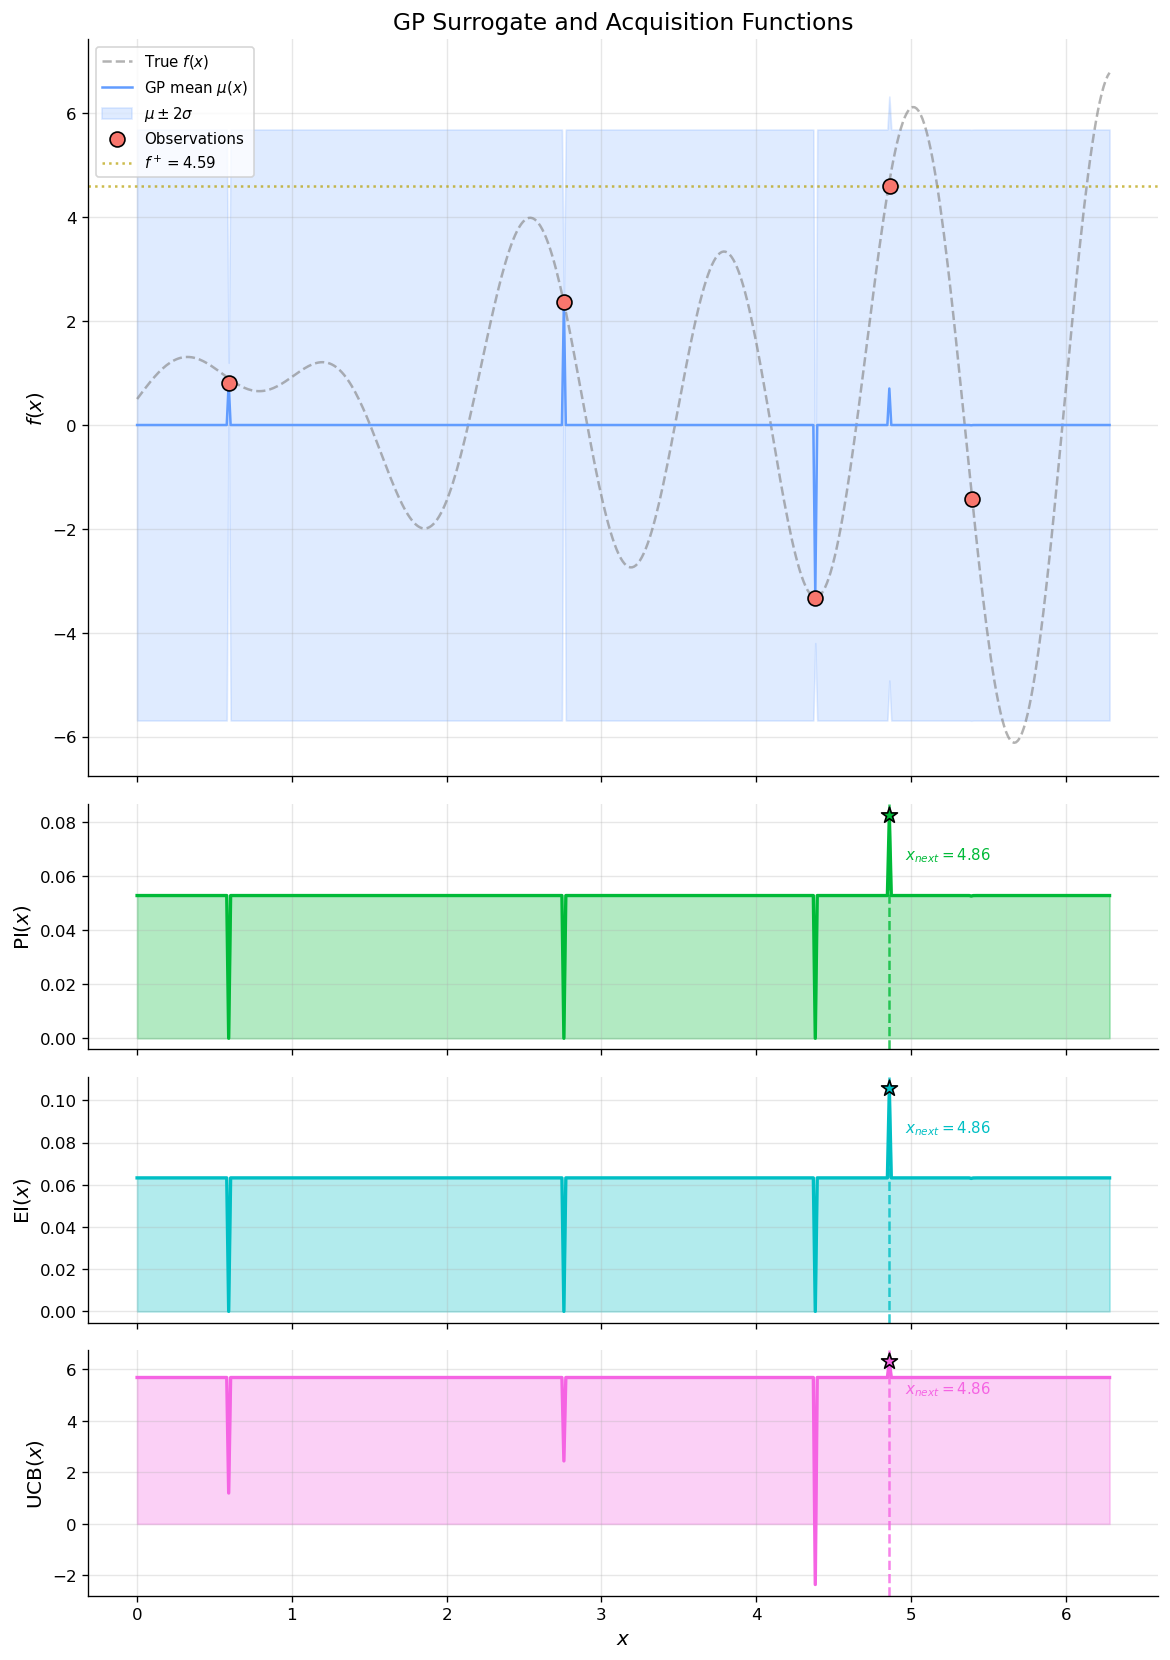

In [3]:
# --- 1D visualisation of GP posterior and acquisition functions ---

# A wiggly test function
def test_func_1d(x):
    return np.sin(3 * x) + x * np.cos(5 * x) + 0.5


# Dense grid for plotting
X_plot = np.linspace(0, 2 * np.pi, 500).reshape(-1, 1)
y_true = test_func_1d(X_plot.ravel())

# A few initial observations
X_obs = rng.uniform(0, 2 * np.pi, size=5).reshape(-1, 1)
y_obs = test_func_1d(X_obs.ravel()) + rng.normal(0, 0.1, size=5)

# Fit GP
kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(
    noise_level=0.01
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp.fit(X_obs, y_obs)

mu, sigma = gp.predict(X_plot, return_std=True)
f_best = np.max(y_obs)

# Compute acquisition functions
pi_vals = probability_of_improvement(mu, sigma, f_best)
ei_vals = expected_improvement(mu, sigma, f_best)
ucb_vals = upper_confidence_bound(mu, sigma, kappa=2.0)

# --- Plot ---
fig, axes = plt.subplots(
    4, 1, figsize=(10, 14), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1, 1]}
)

# Panel 1: GP posterior
ax = axes[0]
ax.plot(X_plot, y_true, "--", color="gray", alpha=0.6, label="True $f(x)$")
ax.plot(X_plot, mu, color=PERIWINKLE, label="GP mean $\\mu(x)$")
ax.fill_between(
    X_plot.ravel(),
    mu - 2 * sigma,
    mu + 2 * sigma,
    alpha=0.2,
    color=PERIWINKLE,
    label="$\\mu \\pm 2\\sigma$",
)
ax.scatter(
    X_obs.ravel(), y_obs, c=SALMON, s=80, zorder=5, edgecolors="k", label="Observations"
)
ax.axhline(f_best, color=GOLD, ls=":", alpha=0.7, label=f"$f^+ = {f_best:.2f}$")
ax.set_ylabel("$f(x)$")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("GP Surrogate and Acquisition Functions", fontsize=14)

# Panels 2-4: Acquisition functions
acq_data = [
    (pi_vals, "PI$(x)$", EMERALD),
    (ei_vals, "EI$(x)$", CYAN),
    (ucb_vals, "UCB$(x)$", ORCHID),
]

for ax, (vals, label, color) in zip(axes[1:], acq_data):
    ax.fill_between(X_plot.ravel(), 0, vals, alpha=0.3, color=color)
    ax.plot(X_plot.ravel(), vals, color=color, lw=2)
    x_next = X_plot.ravel()[np.argmax(vals)]
    ax.axvline(x_next, color=color, ls="--", alpha=0.8)
    ax.scatter(
        [x_next],
        [np.max(vals)],
        color=color,
        s=100,
        zorder=5,
        edgecolors="k",
        marker="*",
    )
    ax.set_ylabel(label)
    ax.text(
        x_next + 0.1,
        np.max(vals) * 0.8,
        f"$x_{{next}}={x_next:.2f}$",
        fontsize=9,
        color=color,
    )

axes[-1].set_xlabel("$x$")
plt.tight_layout()
plt.show()

Notice how the three acquisition functions propose different next query points:

- **PI** tends to be the most exploitative, favouring points near the current best.
- **EI** balances exploitation and exploration, often choosing points where the GP mean is high *and* uncertainty is appreciable.
- **UCB** is explicitly tuneable via $\kappa$ — with $\kappa = 2$ it includes substantial exploration, often venturing into unsampled regions.

In the molecular design context, this means EI and UCB are more likely to discover structurally novel active compounds, while PI will tend to refine known active scaffolds.

---

## 4. From-Scratch BO Loop (1D)

We now implement the complete Bayesian optimisation loop from scratch. We use the same wiggly test function from above:

$$
f(x) = \sin(3x) + x\cos(5x) + 0.5, \qquad x \in [0, 2\pi].
$$

This function has multiple local optima, making it a good testbed. We start from 3 random initial evaluations and run 15 BO iterations using Expected Improvement.

In [4]:
def bo_loop_1d(
    objective,
    bounds,
    n_init=3,
    n_iter=15,
    acq_func="ei",
    xi=0.01,
    kappa=2.0,
    noise=0.05,
    seed=42,
):
    """Run Bayesian Optimisation in 1D.

    Returns
    -------
    X_all : array of all queried x values
    y_all : array of all observed y values
    gp_history : list of fitted GP models (one per iteration)
    """
    local_rng = np.random.default_rng(seed)

    # Initial random samples
    X_all = local_rng.uniform(bounds[0], bounds[1], size=n_init).reshape(-1, 1)
    y_all = objective(X_all.ravel()) + local_rng.normal(0, noise, size=n_init)

    gp_history = []
    X_grid = np.linspace(bounds[0], bounds[1], 500).reshape(-1, 1)

    for i in range(n_iter):
        # Fit GP
        kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(
            noise_level=0.01
        )
        gp = GaussianProcessRegressor(
            kernel=kernel, n_restarts_optimizer=5, random_state=42
        )
        gp.fit(X_all.reshape(-1, 1), y_all)
        gp_history.append(gp)

        # Predict on grid
        mu, sigma = gp.predict(X_grid, return_std=True)
        f_best = np.max(y_all)

        # Compute acquisition function
        if acq_func == "ei":
            acq_vals = expected_improvement(mu, sigma, f_best, xi=xi)
        elif acq_func == "pi":
            acq_vals = probability_of_improvement(mu, sigma, f_best, xi=xi)
        elif acq_func == "ucb":
            acq_vals = upper_confidence_bound(mu, sigma, kappa=kappa)

        # Select next point
        x_next = X_grid[np.argmax(acq_vals)].item()
        y_next = objective(x_next) + local_rng.normal(0, noise)

        X_all = np.append(X_all, x_next)
        y_all = np.append(y_all, y_next)

    return X_all, y_all, gp_history


# Run the BO loop
X_bo, y_bo, gp_models = bo_loop_1d(
    test_func_1d, bounds=(0, 2 * np.pi), n_init=3, n_iter=15, noise=0.05
)

print(f"Best observed value: {np.max(y_bo):.4f} at x = {X_bo[np.argmax(y_bo)]:.4f}")
print(
    f"True global maximum: {np.max(y_true):.4f} at x = {X_plot.ravel()[np.argmax(y_true)]:.4f}"
)

Best observed value: 6.7823 at x = 6.2832
True global maximum: 6.7832 at x = 6.2832


### 4.1 Visualising the BO progression

The following multi-panel figure shows four snapshots of the optimisation process: after 3, 6, 10, and 15 BO iterations (i.e., 6, 9, 13, and 18 total evaluations including the 3 initial points). Watch how the GP posterior becomes increasingly accurate and how the acquisition function concentrates around the true optimum as more data is collected.

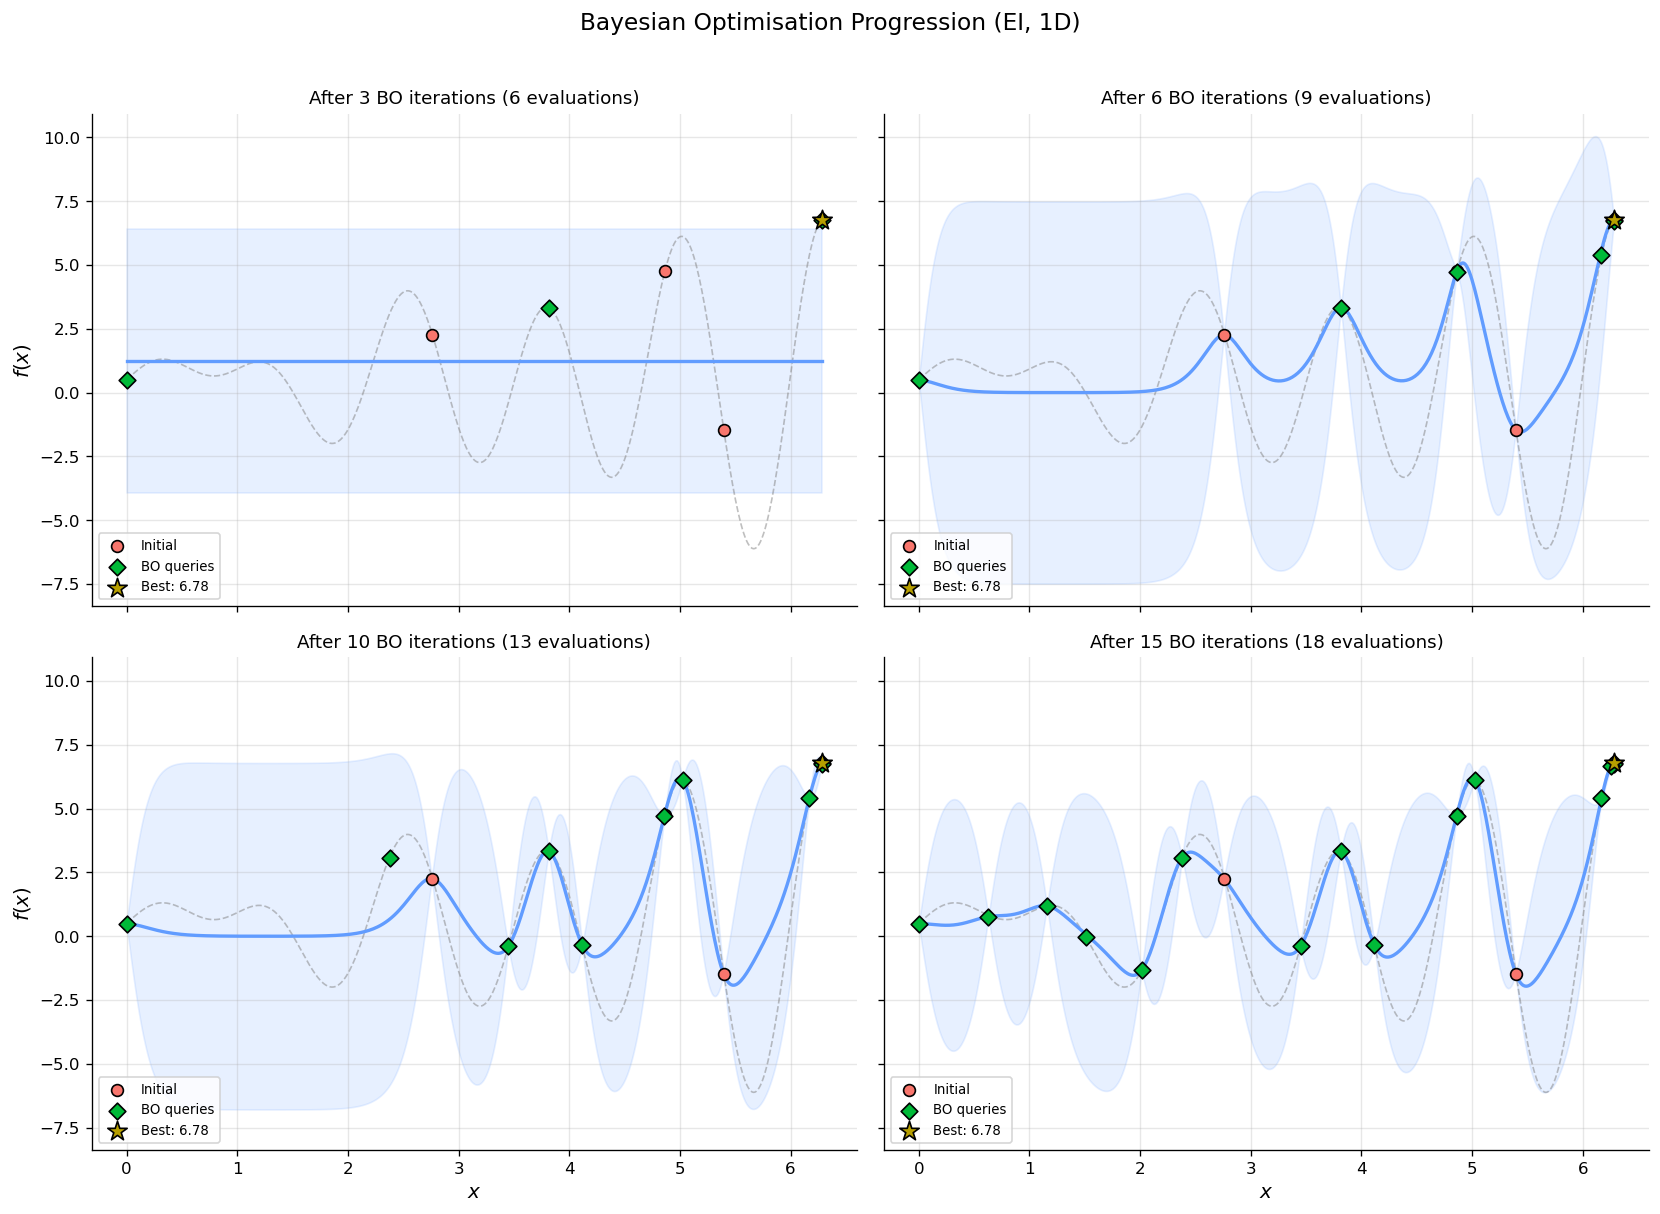

In [5]:
# --- Multi-panel BO progression ---
X_grid = np.linspace(0, 2 * np.pi, 500).reshape(-1, 1)
y_true_grid = test_func_1d(X_grid.ravel())

snapshots = [2, 5, 9, 14]  # indices into gp_history (0-indexed: iter 3, 6, 10, 15)
n_init = 3

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax_idx, snap_idx in enumerate(snapshots):
    ax = axes[ax_idx]
    gp = gp_models[snap_idx]
    n_total = n_init + snap_idx + 1

    mu, sigma = gp.predict(X_grid, return_std=True)

    # True function
    ax.plot(X_grid, y_true_grid, "--", color="gray", alpha=0.5, lw=1)
    # GP posterior
    ax.plot(X_grid, mu, color=PERIWINKLE, lw=2)
    ax.fill_between(
        X_grid.ravel(), mu - 2 * sigma, mu + 2 * sigma, alpha=0.15, color=PERIWINKLE
    )
    # Observations up to this point
    X_so_far = X_bo[:n_total]
    y_so_far = y_bo[:n_total]
    ax.scatter(
        X_so_far[:n_init],
        y_so_far[:n_init],
        c=SALMON,
        s=50,
        zorder=5,
        edgecolors="k",
        label="Initial",
    )
    if n_total > n_init:
        ax.scatter(
            X_so_far[n_init:],
            y_so_far[n_init:],
            c=EMERALD,
            s=50,
            zorder=5,
            edgecolors="k",
            marker="D",
            label="BO queries",
        )
    # Best so far
    best_idx = np.argmax(y_so_far)
    ax.scatter(
        [X_so_far[best_idx]],
        [y_so_far[best_idx]],
        c=GOLD,
        s=150,
        zorder=6,
        edgecolors="k",
        marker="*",
        label=f"Best: {y_so_far[best_idx]:.2f}",
    )

    ax.set_title(
        f"After {snap_idx + 1} BO iterations ({n_total} evaluations)", fontsize=11
    )
    ax.legend(fontsize=8, loc="lower left")

axes[2].set_xlabel("$x$")
axes[3].set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
axes[2].set_ylabel("$f(x)$")

fig.suptitle("Bayesian Optimisation Progression (EI, 1D)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Convergence comparison: BO vs random search

To appreciate the sample efficiency of Bayesian optimisation, we compare its convergence against **random search** (which simply evaluates $f$ at uniformly sampled points). The plot below shows the best observed value as a function of the number of evaluations. BO should find a near-optimal value much faster.

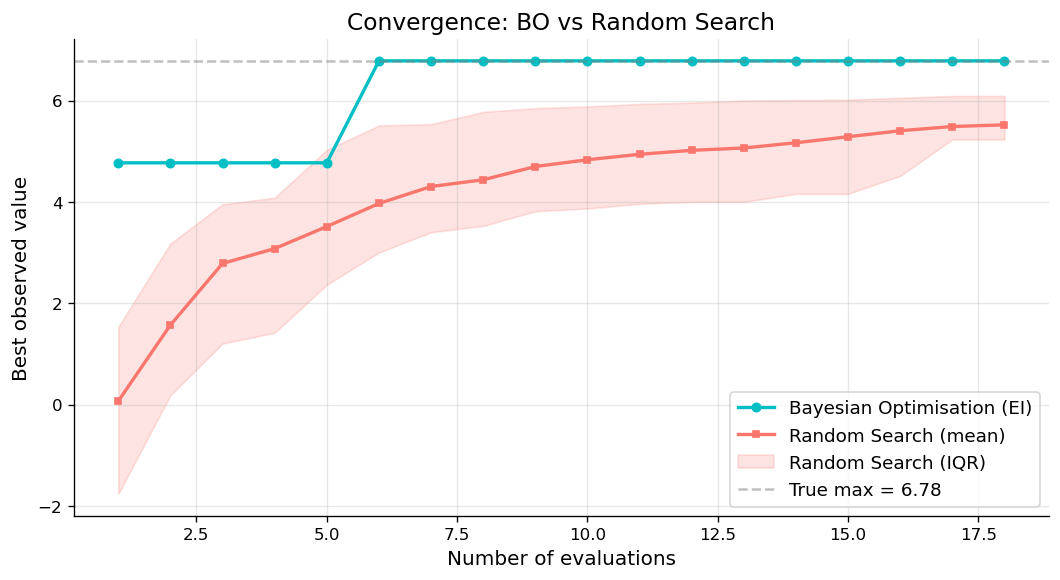

In [6]:
# --- Convergence comparison: BO vs Random Search ---

n_total_evals = len(X_bo)

# BO convergence
bo_best = np.maximum.accumulate(y_bo)

# Random search (average over multiple runs)
n_random_runs = 50
random_bests = np.zeros((n_random_runs, n_total_evals))
for run in range(n_random_runs):
    run_rng = np.random.default_rng(run)
    X_rand = run_rng.uniform(0, 2 * np.pi, size=n_total_evals)
    y_rand = test_func_1d(X_rand) + run_rng.normal(0, 0.05, size=n_total_evals)
    random_bests[run] = np.maximum.accumulate(y_rand)

random_mean = random_bests.mean(axis=0)
random_q25 = np.percentile(random_bests, 25, axis=0)
random_q75 = np.percentile(random_bests, 75, axis=0)

# True maximum
true_max = np.max(y_true)

fig, ax = plt.subplots(figsize=(9, 5))
evals = np.arange(1, n_total_evals + 1)

ax.plot(
    evals,
    bo_best,
    "-o",
    color=CYAN,
    lw=2,
    markersize=5,
    label="Bayesian Optimisation (EI)",
)
ax.plot(
    evals,
    random_mean,
    "-s",
    color=SALMON,
    lw=2,
    markersize=4,
    label="Random Search (mean)",
)
ax.fill_between(
    evals, random_q25, random_q75, alpha=0.2, color=SALMON, label="Random Search (IQR)"
)
ax.axhline(
    true_max, color="gray", ls="--", alpha=0.5, label=f"True max = {true_max:.2f}"
)

ax.set_xlabel("Number of evaluations")
ax.set_ylabel("Best observed value")
ax.set_title("Convergence: BO vs Random Search")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The Bayesian optimisation curve should reach near-optimal values significantly faster than random search. In the molecular design context, this difference translates directly into fewer compounds synthesised and fewer experiments run — potentially saving weeks of lab time per optimisation campaign.

---

## 5. Application — Molecular Property Optimisation

We now apply Bayesian optimisation to a realistic (though synthetic) molecular property optimisation task in two dimensions.

### 5.1 Problem setup

**Scenario:** we have a library of 500 candidate molecules, each described by two physicochemical descriptors:

- **Descriptor 1:** normalised LogP (lipophilicity) $\in [0, 1]$
- **Descriptor 2:** normalised molecular weight $\in [0, 1]$

The target property is **aqueous solubility** (logS). Measuring logS experimentally is slow and expensive — each measurement takes a full day of lab work. We want to find the molecule(s) with the best solubility using as few measurements as possible.

We model the true logS landscape as a complex, multi-modal function of the two descriptors — a sum of radial basis functions placed at random centres, creating a surface that looks like a realistic chemical response surface with multiple "hotspots" of high solubility.

In [7]:
# --- Build a synthetic molecular property landscape ---


def build_molecular_landscape(seed=42):
    """Create a multi-modal 2D landscape resembling a molecular property surface.

    Returns a function f(X) where X has shape (n, 2) with values in [0, 1]^2.
    """
    land_rng = np.random.default_rng(seed)

    # Place RBF centres
    n_peaks = 8
    centres = land_rng.uniform(0.1, 0.9, size=(n_peaks, 2))
    heights = land_rng.uniform(0.5, 2.0, size=n_peaks)
    widths = land_rng.uniform(0.05, 0.2, size=n_peaks)

    # One dominant global peak
    centres[0] = [0.72, 0.35]
    heights[0] = 2.5
    widths[0] = 0.12

    # A secondary peak
    centres[1] = [0.25, 0.75]
    heights[1] = 2.0
    widths[1] = 0.10

    def landscape(X):
        """X: (n, 2) array -> (n,) array of logS values."""
        X = np.atleast_2d(X)
        result = np.zeros(X.shape[0])
        for c, h, w in zip(centres, heights, widths):
            dist_sq = np.sum((X - c) ** 2, axis=1)
            result += h * np.exp(-dist_sq / (2 * w**2))
        # Add a gentle global trend (higher logP -> lower solubility)
        result -= 0.8 * X[:, 0]
        # Add some mild sinusoidal texture
        result += 0.3 * np.sin(4 * np.pi * X[:, 0]) * np.cos(3 * np.pi * X[:, 1])
        return result

    return landscape


logS_func = build_molecular_landscape(seed=42)

# Create grid for visualisation
grid_res = 200
x1_grid = np.linspace(0, 1, grid_res)
x2_grid = np.linspace(0, 1, grid_res)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid_2d = np.column_stack([X1.ravel(), X2.ravel()])
Z_true = logS_func(X_grid_2d).reshape(grid_res, grid_res)

# Find true optimum
opt_idx = np.argmax(Z_true)
opt_x1, opt_x2 = X1.ravel()[opt_idx], X2.ravel()[opt_idx]
opt_val = Z_true.ravel()[opt_idx]

print(f"True optimum: logS = {opt_val:.3f} at (LogP={opt_x1:.3f}, MW={opt_x2:.3f})")

True optimum: logS = 3.533 at (LogP=0.241, MW=0.789)


The cell below visualises the true logS landscape as a contour plot. The global optimum is marked with a star. In a real setting, we would *not* have access to this surface — we can only observe it one expensive point at a time.

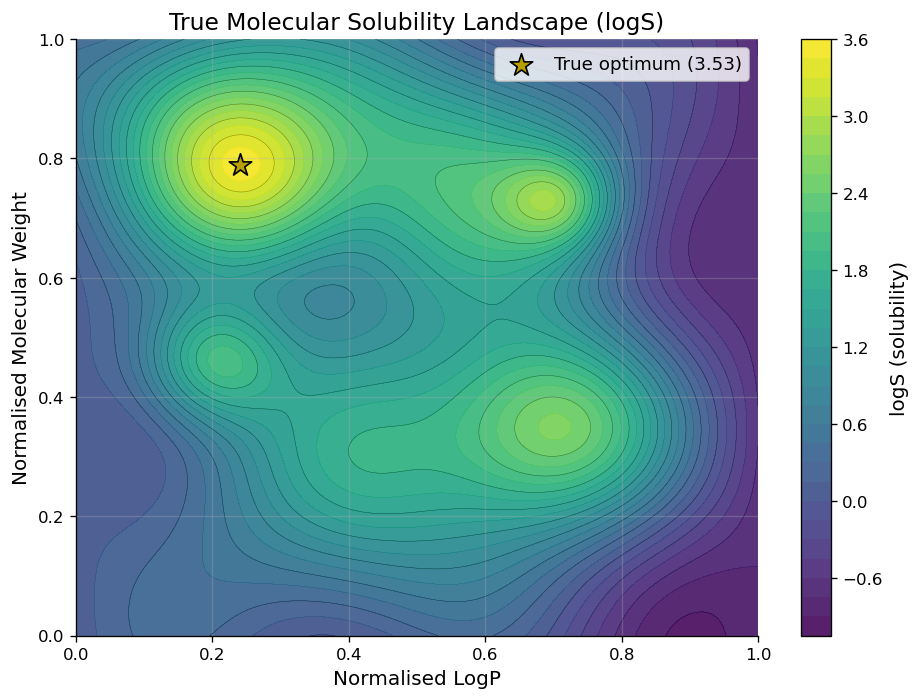

In [8]:
# --- Visualise the true landscape ---
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X1, X2, Z_true, levels=30, cmap="viridis", alpha=0.9)
ax.contour(X1, X2, Z_true, levels=15, colors="k", linewidths=0.3, alpha=0.4)
cbar = fig.colorbar(contour, ax=ax, label="logS (solubility)")
ax.scatter(
    [opt_x1],
    [opt_x2],
    c=GOLD,
    s=200,
    marker="*",
    edgecolors="k",
    zorder=10,
    label=f"True optimum ({opt_val:.2f})",
)
ax.set_xlabel("Normalised LogP")
ax.set_ylabel("Normalised Molecular Weight")
ax.set_title("True Molecular Solubility Landscape (logS)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 5.2 Running BO in 2D

We now run Bayesian optimisation on this landscape. Starting from 5 initial random evaluations, we perform 25 BO iterations using Expected Improvement. At each step, the GP is refit to all available data, and the next query point is chosen by maximising EI over a dense grid of candidate points.

In [9]:
def bo_loop_2d(objective, n_init=5, n_iter=25, xi=0.01, noise=0.05, seed=123):
    """Run 2D Bayesian Optimisation with Expected Improvement.

    Returns
    -------
    X_all : (n_init + n_iter, 2) array
    y_all : (n_init + n_iter,) array
    gp_snapshots : dict mapping iteration -> fitted GP
    """
    local_rng = np.random.default_rng(seed)

    # Candidate grid for acquisition optimisation
    res = 80
    g1 = np.linspace(0, 1, res)
    g2 = np.linspace(0, 1, res)
    G1, G2 = np.meshgrid(g1, g2)
    X_cand = np.column_stack([G1.ravel(), G2.ravel()])

    # Initial random samples
    X_all = local_rng.uniform(0, 1, size=(n_init, 2))
    y_all = objective(X_all) + local_rng.normal(0, noise, size=n_init)

    snapshot_iters = {4, 9, 14, 24}  # save GP at these BO iterations (0-indexed)
    gp_snapshots = {}

    for i in range(n_iter):
        # Fit GP
        kernel = ConstantKernel(1.0) * Matern(length_scale=0.3, nu=2.5) + WhiteKernel(
            noise_level=0.01
        )
        gp = GaussianProcessRegressor(
            kernel=kernel, n_restarts_optimizer=5, random_state=42
        )
        gp.fit(X_all, y_all)

        if i in snapshot_iters:
            gp_snapshots[i] = gp

        # Compute EI on candidate grid
        mu, sigma = gp.predict(X_cand, return_std=True)
        f_best = np.max(y_all)
        ei = expected_improvement(mu, sigma, f_best, xi=xi)

        # Select next point
        next_idx = np.argmax(ei)
        x_next = X_cand[next_idx]
        y_next = objective(x_next.reshape(1, -1)).item() + local_rng.normal(0, noise)

        X_all = np.vstack([X_all, x_next])
        y_all = np.append(y_all, y_next)

    return X_all, y_all, gp_snapshots


X_bo2d, y_bo2d, gp_snaps = bo_loop_2d(logS_func, n_init=5, n_iter=25, noise=0.05)

best_idx_2d = np.argmax(y_bo2d)
print(
    f"Best observed: logS = {y_bo2d[best_idx_2d]:.3f} "
    f"at (LogP={X_bo2d[best_idx_2d, 0]:.3f}, MW={X_bo2d[best_idx_2d, 1]:.3f})"
)
print(f"True optimum:  logS = {opt_val:.3f} at (LogP={opt_x1:.3f}, MW={opt_x2:.3f})")

Best observed: logS = 3.604 at (LogP=0.253, MW=0.785)
True optimum:  logS = 3.533 at (LogP=0.241, MW=0.789)


### 5.3 Visualising the 2D search

The figure below shows four snapshots of the BO search in the 2D descriptor space. Each panel displays the GP posterior mean (contours), all evaluated points so far (circles for initial, diamonds for BO-selected), and the current best point (star). Watch how the algorithm initially explores the space and then concentrates evaluations near the global optimum.

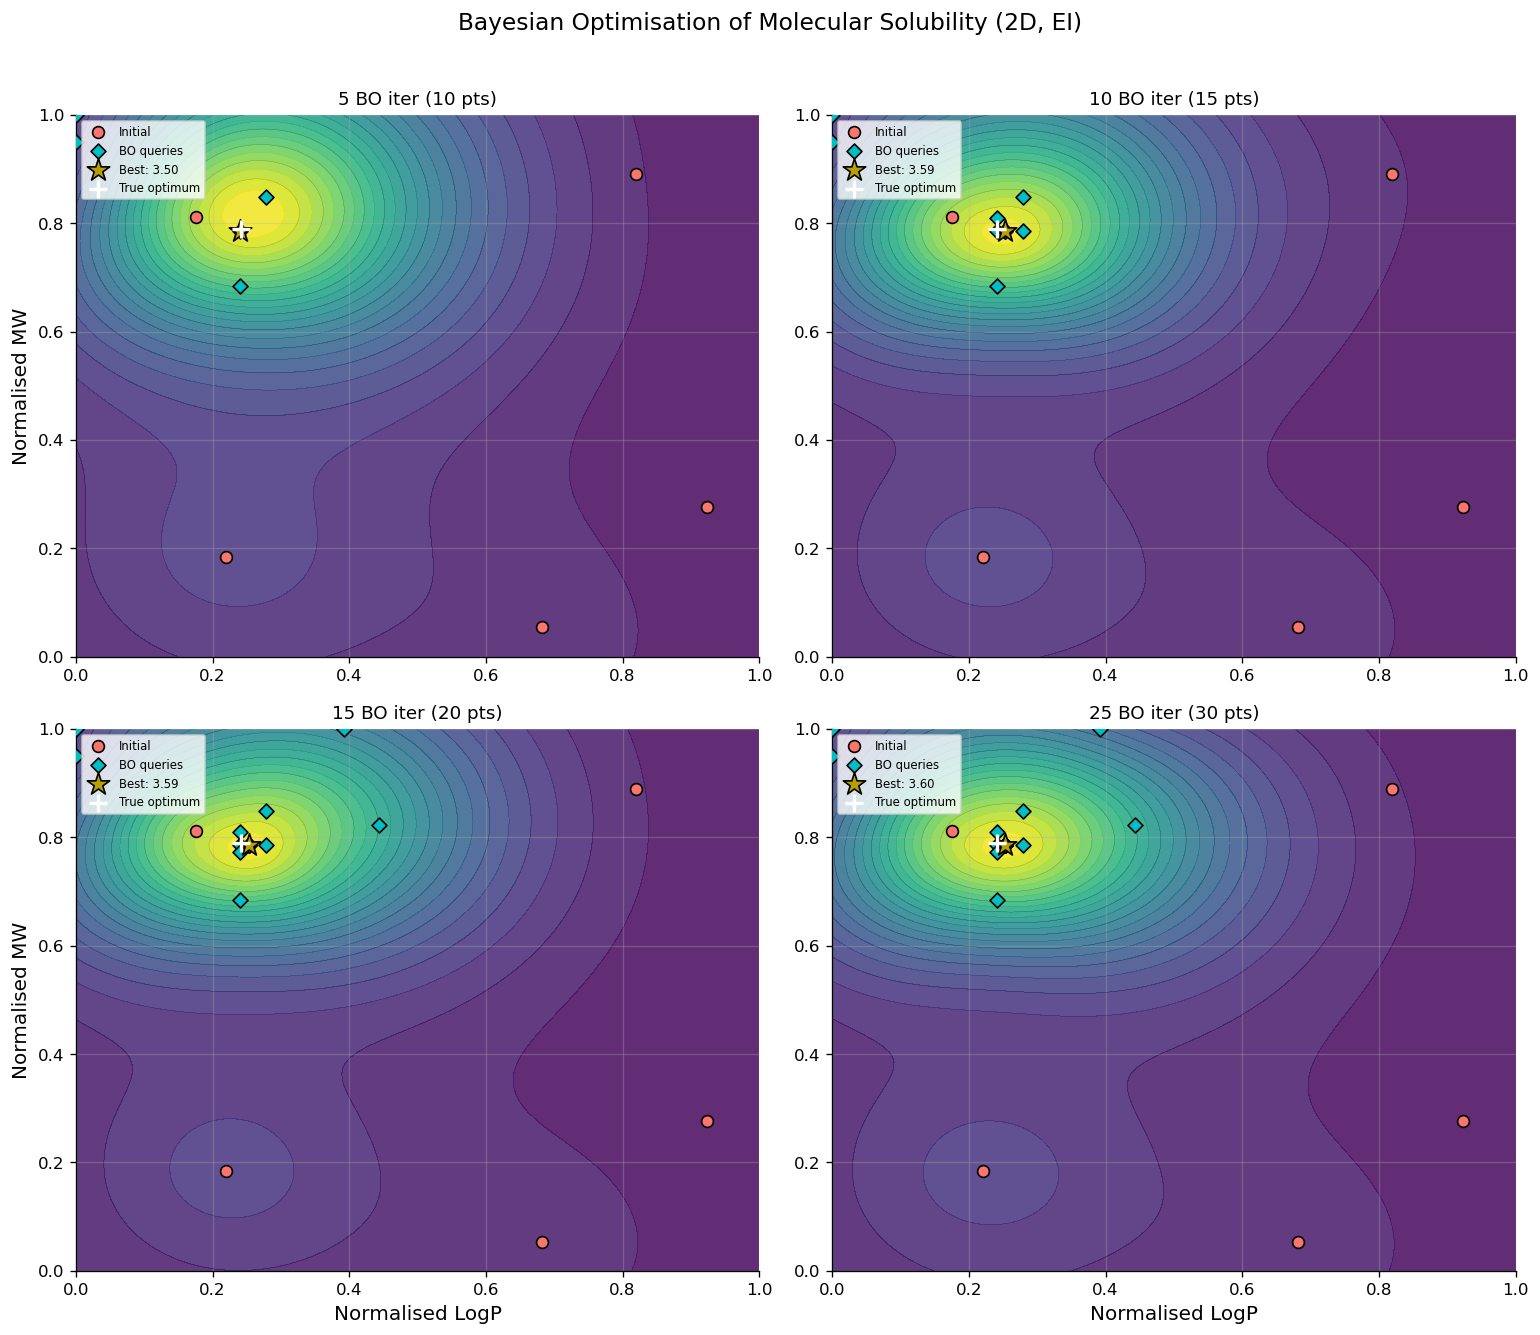

In [10]:
# --- 2x2 snapshot of 2D BO ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

# Finer grid for GP prediction contours
res_plot = 100
gp1 = np.linspace(0, 1, res_plot)
gp2 = np.linspace(0, 1, res_plot)
GP1, GP2 = np.meshgrid(gp1, gp2)
X_pred = np.column_stack([GP1.ravel(), GP2.ravel()])

n_init = 5
snap_labels = [
    (4, "5 BO iter (10 pts)"),
    (9, "10 BO iter (15 pts)"),
    (14, "15 BO iter (20 pts)"),
    (24, "25 BO iter (30 pts)"),
]

for ax, (snap_iter, title) in zip(axes, snap_labels):
    gp = gp_snaps[snap_iter]
    mu_2d = gp.predict(X_pred).reshape(res_plot, res_plot)

    n_total = n_init + snap_iter + 1
    X_pts = X_bo2d[:n_total]
    y_pts = y_bo2d[:n_total]

    # GP mean contour
    cf = ax.contourf(GP1, GP2, mu_2d, levels=25, cmap="viridis", alpha=0.85)
    ax.contour(GP1, GP2, mu_2d, levels=12, colors="k", linewidths=0.2, alpha=0.3)

    # Initial points
    ax.scatter(
        X_pts[:n_init, 0],
        X_pts[:n_init, 1],
        c=SALMON,
        s=50,
        edgecolors="k",
        zorder=5,
        label="Initial",
    )
    # BO points
    if n_total > n_init:
        ax.scatter(
            X_pts[n_init:, 0],
            X_pts[n_init:, 1],
            c=CYAN,
            s=40,
            edgecolors="k",
            marker="D",
            zorder=5,
            label="BO queries",
        )
    # Best point
    best_i = np.argmax(y_pts)
    ax.scatter(
        [X_pts[best_i, 0]],
        [X_pts[best_i, 1]],
        c=GOLD,
        s=200,
        marker="*",
        edgecolors="k",
        zorder=6,
        label=f"Best: {y_pts[best_i]:.2f}",
    )
    # True optimum
    ax.scatter(
        [opt_x1],
        [opt_x2],
        c="white",
        s=120,
        marker="+",
        linewidths=2,
        zorder=7,
        label="True optimum",
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc="upper left")

axes[2].set_xlabel("Normalised LogP")
axes[3].set_xlabel("Normalised LogP")
axes[0].set_ylabel("Normalised MW")
axes[2].set_ylabel("Normalised MW")

fig.suptitle(
    "Bayesian Optimisation of Molecular Solubility (2D, EI)", fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

### 5.4 Convergence comparison: BO vs random search vs grid search

We now compare the convergence of three strategies:

1. **Bayesian optimisation (EI):** the adaptive, model-guided approach.
2. **Random search:** evaluate at uniformly random points.
3. **Grid search:** evaluate on a regular grid (for the same total budget).

BO should reach near-optimal values with substantially fewer evaluations.

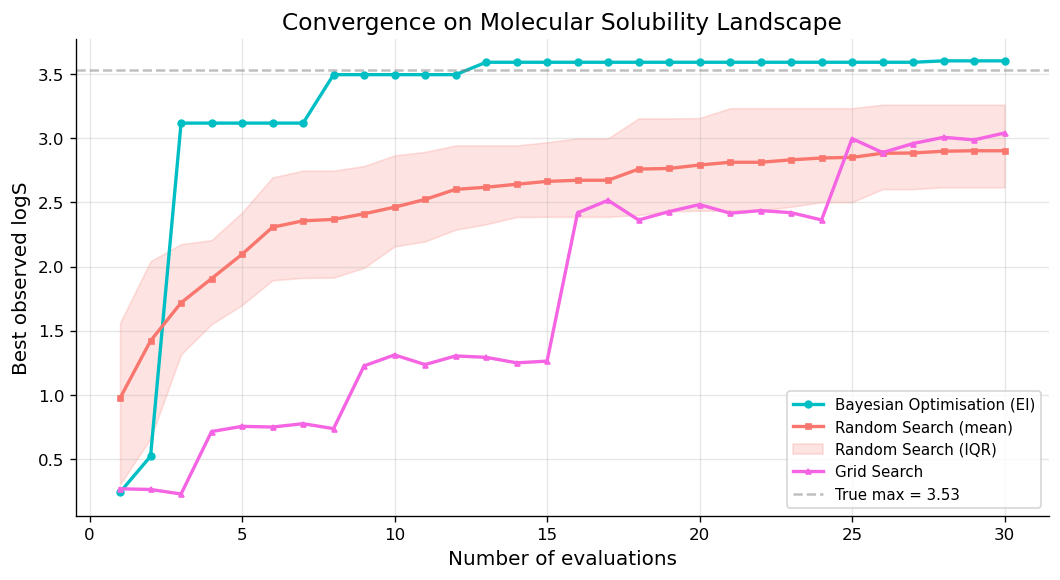

In [11]:
# --- Convergence comparison in 2D ---
n_total = len(y_bo2d)
bo_best_2d = np.maximum.accumulate(y_bo2d)

# Random search (multiple runs)
n_runs = 50
rand_bests_2d = np.zeros((n_runs, n_total))
for run in range(n_runs):
    r = np.random.default_rng(run + 1000)
    X_r = r.uniform(0, 1, size=(n_total, 2))
    y_r = logS_func(X_r) + r.normal(0, 0.05, size=n_total)
    rand_bests_2d[run] = np.maximum.accumulate(y_r)

rand_mean_2d = rand_bests_2d.mean(axis=0)
rand_q25_2d = np.percentile(rand_bests_2d, 25, axis=0)
rand_q75_2d = np.percentile(rand_bests_2d, 75, axis=0)

# Grid search: evaluate on a sqrt(n_total) x sqrt(n_total) grid at each budget
grid_bests = []
for n_budget in range(1, n_total + 1):
    side = max(1, int(np.sqrt(n_budget)))
    g1 = np.linspace(0.05, 0.95, side)
    g2 = np.linspace(0.05, 0.95, side)
    G1g, G2g = np.meshgrid(g1, g2)
    X_g = np.column_stack([G1g.ravel(), G2g.ravel()])[:n_budget]
    y_g = logS_func(X_g) + rng.normal(0, 0.05, size=len(X_g))
    grid_bests.append(np.max(y_g))
grid_bests = np.array(grid_bests)

fig, ax = plt.subplots(figsize=(9, 5))
evals = np.arange(1, n_total + 1)

ax.plot(
    evals,
    bo_best_2d,
    "-o",
    color=CYAN,
    lw=2,
    markersize=4,
    label="Bayesian Optimisation (EI)",
)
ax.plot(
    evals,
    rand_mean_2d,
    "-s",
    color=SALMON,
    lw=2,
    markersize=3,
    label="Random Search (mean)",
)
ax.fill_between(
    evals,
    rand_q25_2d,
    rand_q75_2d,
    alpha=0.2,
    color=SALMON,
    label="Random Search (IQR)",
)
ax.plot(evals, grid_bests, "-^", color=ORCHID, lw=2, markersize=3, label="Grid Search")
ax.axhline(opt_val, color="gray", ls="--", alpha=0.5, label=f"True max = {opt_val:.2f}")

ax.set_xlabel("Number of evaluations")
ax.set_ylabel("Best observed logS")
ax.set_title("Convergence on Molecular Solubility Landscape")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

The convergence plot makes the case for Bayesian optimisation compellingly. With the same evaluation budget, BO consistently finds better solutions than both random search and grid search. In the molecular design context, this means:

- **Fewer compounds synthesised** to reach the same target property.
- **Faster design--make--test--analyse cycles** in lead optimisation.
- **Better outcomes** when the experimental budget is fixed.

The advantage of BO is most pronounced in the **early** iterations (the first 10--15 evaluations), which is precisely the regime that matters in practice: lab budgets are limited, and early wins save the most time.

---

## 6. Practical Considerations in Molecular BO

The basic BO framework we implemented above captures the core idea, but real-world molecular optimisation involves several additional challenges and extensions.

### 6.1 Batch Bayesian Optimisation

In practice, a medicinal chemistry team can synthesise and test **multiple compounds in parallel** within a single DMTA cycle. This calls for **batch acquisition functions** that select a *set* of $q$ points simultaneously, rather than a single point.

Common batch strategies include:

- **q-EI (multi-point Expected Improvement):** jointly maximise the expected improvement over a batch of $q$ points. Exact computation is expensive ($q$-dimensional integration); approximations include the **constant liar** heuristic (Ginsbourger et al., 2010) and **Monte Carlo estimation** (Wilson et al., 2018).
- **Kriging Believer:** after selecting each point in the batch, "hallucinate" its observation as the GP mean, refit, and select the next point. Simple and effective.
- **Thompson Sampling:** draw $q$ independent posterior samples from the GP and maximise each one. The resulting batch naturally diversifies.

### 6.2 Multi-objective Bayesian Optimisation

Drug discovery rarely involves optimising a single property. Typically, we want to simultaneously:

- Maximise binding affinity
- Maximise metabolic stability
- Minimise toxicity (hERG inhibition, Ames test)
- Stay within drug-like property ranges

This is a **multi-objective optimisation** problem. The goal shifts from finding a single optimum to identifying the **Pareto front** — the set of molecules where no property can be improved without worsening another.

Multi-objective acquisition functions include **Expected Hypervolume Improvement (EHVI)** (Emmerich et al., 2006) and **ParEGO** (Knowles, 2006), which scalarises objectives with random weight vectors.

### 6.3 Constrained Bayesian Optimisation

In addition to optimising properties, candidate molecules must satisfy hard constraints. **Lipinski's Rule of Five** requires:

- Molecular weight $\leq 500$ Da
- LogP $\leq 5$
- Hydrogen bond donors $\leq 5$
- Hydrogen bond acceptors $\leq 10$

In constrained BO, we model the constraint function(s) with additional GPs and modify the acquisition function. For example, **Expected Improvement with Constraints (EIC):**

$$
\text{EIC}(x) = \text{EI}(x) \cdot P(\text{constraints satisfied} \mid x).
$$

### 6.4 Choice of molecular representation

The success of BO depends critically on the input representation $x$:

| Representation                                    | Pros                             | Cons                                            |
|:--------------------------------------------------|:---------------------------------|:------------------------------------------------|
| Physicochemical descriptors (LogP, MW, TPSA, ...) | Low-dimensional, interpretable   | May miss structural information                 |
| Molecular fingerprints (ECFP, MACCS)              | Capture substructure information | High-dimensional, sparse                        |
| Learned latent spaces (VAE, GNN)                  | Smooth, continuous               | Requires large training set; less interpretable |

The kernel choice should match the representation. For fingerprints, the **Tanimoto kernel** (a valid Mercer kernel) is standard. For continuous descriptors, the Mat\'{e}rn or RBF kernels work well.

### 6.5 When to use BO

Bayesian optimisation is the right tool when:

- Each evaluation is **expensive** (> minutes/hours per evaluation)
- The budget is **small** (< 500--1000 evaluations)
- The objective is **black-box** (no gradients available)
- The search space is **continuous** or mixed continuous/categorical and **moderate-dimensional** ($d \lesssim 20$)

For cheap evaluations (milliseconds per call), evolutionary algorithms, Bayesian neural networks, or even exhaustive screening may be more appropriate. For very high-dimensional spaces ($d > 50$), vanilla GP-based BO struggles due to the curse of dimensionality; high-dimensional extensions (random embeddings, additive kernels, trust regions) are an active area of research.

---

## 7. Connection to Reaction Optimisation

Beyond molecular design, Bayesian optimisation has become a powerful tool for **chemical reaction optimisation** — finding the best conditions (temperature, solvent, catalyst loading, concentration, time) to maximise yield or selectivity.

### 7.1 Why BO for reactions?

The same principles apply: each experiment is expensive (requires lab time and reagents), the response surface is complex and unknown, and we want to find the optimum in as few experiments as possible. Traditional approaches — one-variable-at-a-time (OVAT) or full factorial design — are either inefficient or require too many experiments.

Shields et al. (*Nature*, 2021) demonstrated that BO can outperform human experts in optimising palladium-catalysed cross-coupling reactions, finding optimal conditions in 50% fewer experiments than experienced chemists.

### 7.2 Example: Optimising a synthetic yield surface

We construct a synthetic 2D yield surface as a function of **temperature** (normalised to $[0, 1]$) and **catalyst loading** (normalised to $[0, 1]$). The true yield surface has a sharp optimum — typical of real reaction optimisation — where a narrow temperature window at moderate catalyst loading gives the best result.

In [12]:
# --- Synthetic reaction yield surface ---


def reaction_yield(X):
    """Synthetic 2D yield surface: temperature x catalyst loading.
    X: (n, 2) array with values in [0, 1].
    """
    X = np.atleast_2d(X)
    temp, cat = X[:, 0], X[:, 1]

    # Main peak: moderate-high temperature, moderate catalyst
    main = 90 * np.exp(
        -((temp - 0.65) ** 2 / (2 * 0.08**2) + (cat - 0.45) ** 2 / (2 * 0.12**2))
    )
    # Secondary peak: low temperature, high catalyst (kinetic control)
    secondary = 55 * np.exp(
        -((temp - 0.25) ** 2 / (2 * 0.10**2) + (cat - 0.80) ** 2 / (2 * 0.08**2))
    )
    # Penalty at extremes
    penalty = -20 * (temp**3 + (1 - cat) ** 3)
    # Baseline
    base = 15 + 10 * np.sin(2 * np.pi * temp) * np.cos(np.pi * cat)

    return main + secondary + penalty + base


# Evaluate on grid
res_rxn = 150
t_grid = np.linspace(0, 1, res_rxn)
c_grid = np.linspace(0, 1, res_rxn)
T_grid, C_grid = np.meshgrid(t_grid, c_grid)
X_rxn_grid = np.column_stack([T_grid.ravel(), C_grid.ravel()])
Y_rxn = reaction_yield(X_rxn_grid).reshape(res_rxn, res_rxn)

rxn_opt_idx = np.argmax(Y_rxn)
rxn_opt_t = T_grid.ravel()[rxn_opt_idx]
rxn_opt_c = C_grid.ravel()[rxn_opt_idx]
rxn_opt_val = Y_rxn.ravel()[rxn_opt_idx]

print(
    f"True optimum: yield = {rxn_opt_val:.1f}% at "
    f"(temp={rxn_opt_t:.3f}, cat={rxn_opt_c:.3f})"
)

True optimum: yield = 95.0% at (temp=0.651, cat=0.456)


We now run BO on this reaction yield surface using the same EI-based loop, starting from 4 random experiments and running 20 iterations. The convergence plot below shows how quickly BO homes in on the high-yield region.

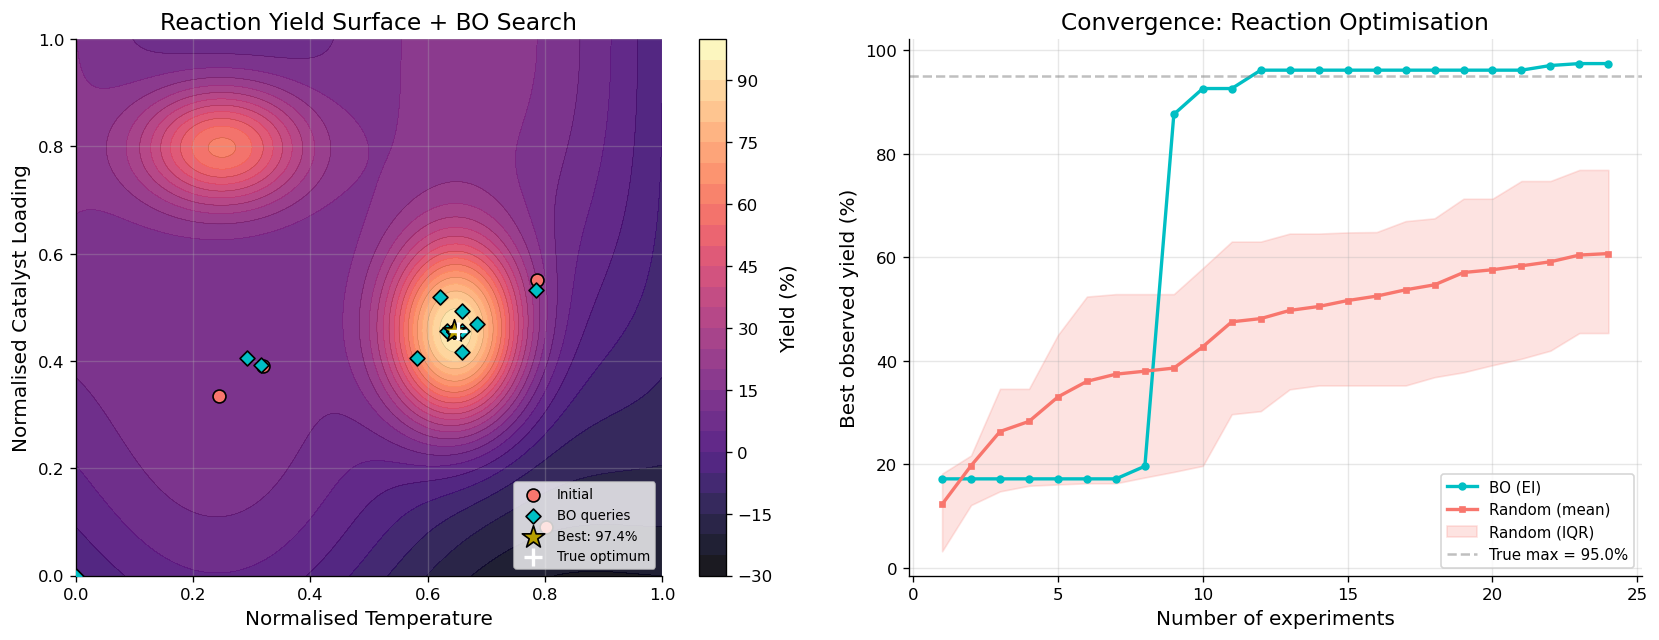

In [13]:
# --- BO on reaction yield surface + convergence ---


def bo_loop_generic_2d(objective, n_init=4, n_iter=20, xi=0.01, noise=1.0, seed=77):
    """Generic 2D BO loop with EI. Returns X_all, y_all."""
    local_rng = np.random.default_rng(seed)

    res = 80
    g1 = np.linspace(0, 1, res)
    g2 = np.linspace(0, 1, res)
    G1, G2 = np.meshgrid(g1, g2)
    X_cand = np.column_stack([G1.ravel(), G2.ravel()])

    X_all = local_rng.uniform(0, 1, size=(n_init, 2))
    y_all = objective(X_all) + local_rng.normal(0, noise, size=n_init)

    for i in range(n_iter):
        kernel = ConstantKernel(1.0) * Matern(length_scale=0.3, nu=2.5) + WhiteKernel(
            noise_level=1.0
        )
        gp = GaussianProcessRegressor(
            kernel=kernel, n_restarts_optimizer=5, random_state=42
        )
        gp.fit(X_all, y_all)

        mu, sigma = gp.predict(X_cand, return_std=True)
        f_best = np.max(y_all)
        ei = expected_improvement(mu, sigma, f_best, xi=xi)

        x_next = X_cand[np.argmax(ei)]
        y_next = objective(x_next.reshape(1, -1)).item() + local_rng.normal(0, noise)
        X_all = np.vstack([X_all, x_next])
        y_all = np.append(y_all, y_next)

    return X_all, y_all


X_rxn_bo, y_rxn_bo = bo_loop_generic_2d(
    reaction_yield, n_init=4, n_iter=20, noise=1.5, seed=77
)

# Random search comparison
n_rxn_total = len(y_rxn_bo)
n_rxn_runs = 50
rand_rxn = np.zeros((n_rxn_runs, n_rxn_total))
for run in range(n_rxn_runs):
    r = np.random.default_rng(run + 2000)
    Xr = r.uniform(0, 1, size=(n_rxn_total, 2))
    yr = reaction_yield(Xr) + r.normal(0, 1.5, size=n_rxn_total)
    rand_rxn[run] = np.maximum.accumulate(yr)

# --- Plots: yield surface + convergence ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: yield surface with BO points
ax = axes[0]
cf = ax.contourf(T_grid, C_grid, Y_rxn, levels=25, cmap="magma", alpha=0.9)
ax.contour(T_grid, C_grid, Y_rxn, levels=12, colors="k", linewidths=0.2, alpha=0.3)
fig.colorbar(cf, ax=ax, label="Yield (%)")
ax.scatter(
    X_rxn_bo[:4, 0],
    X_rxn_bo[:4, 1],
    c=SALMON,
    s=60,
    edgecolors="k",
    zorder=5,
    label="Initial",
)
ax.scatter(
    X_rxn_bo[4:, 0],
    X_rxn_bo[4:, 1],
    c=CYAN,
    s=40,
    edgecolors="k",
    marker="D",
    zorder=5,
    label="BO queries",
)
best_rxn_idx = np.argmax(y_rxn_bo)
ax.scatter(
    [X_rxn_bo[best_rxn_idx, 0]],
    [X_rxn_bo[best_rxn_idx, 1]],
    c=GOLD,
    s=200,
    marker="*",
    edgecolors="k",
    zorder=6,
    label=f"Best: {y_rxn_bo[best_rxn_idx]:.1f}%",
)
ax.scatter(
    [rxn_opt_t],
    [rxn_opt_c],
    c="white",
    s=120,
    marker="+",
    linewidths=2,
    zorder=7,
    label="True optimum",
)
ax.set_xlabel("Normalised Temperature")
ax.set_ylabel("Normalised Catalyst Loading")
ax.set_title("Reaction Yield Surface + BO Search")
ax.legend(fontsize=8, loc="lower right")

# Right: convergence
ax = axes[1]
evals_rxn = np.arange(1, n_rxn_total + 1)
bo_rxn_best = np.maximum.accumulate(y_rxn_bo)
rand_rxn_mean = rand_rxn.mean(axis=0)
rand_rxn_q25 = np.percentile(rand_rxn, 25, axis=0)
rand_rxn_q75 = np.percentile(rand_rxn, 75, axis=0)

ax.plot(evals_rxn, bo_rxn_best, "-o", color=CYAN, lw=2, markersize=4, label="BO (EI)")
ax.plot(
    evals_rxn,
    rand_rxn_mean,
    "-s",
    color=SALMON,
    lw=2,
    markersize=3,
    label="Random (mean)",
)
ax.fill_between(
    evals_rxn, rand_rxn_q25, rand_rxn_q75, alpha=0.2, color=SALMON, label="Random (IQR)"
)
ax.axhline(
    rxn_opt_val,
    color="gray",
    ls="--",
    alpha=0.5,
    label=f"True max = {rxn_opt_val:.1f}%",
)
ax.set_xlabel("Number of experiments")
ax.set_ylabel("Best observed yield (%)")
ax.set_title("Convergence: Reaction Optimisation")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

The left panel shows the BO search overlaid on the true yield surface. Notice how the algorithm concentrates experiments near the high-yield region after initial exploration. The right panel confirms that BO finds near-optimal yield conditions in roughly half the experiments needed by random search.

This example reflects real practice: Shields et al. (2021) showed that BO-guided reaction optimisation in the lab consistently matched or exceeded expert chemist performance while using fewer experiments. The approach has been adopted by pharmaceutical companies for high-throughput experimentation campaigns.

---

## Key Takeaways

1. **Molecular optimisation is expensive.** Whether we are optimising molecular properties (lead optimisation) or reaction conditions, each evaluation requires real lab work. This makes sample efficiency paramount.

2. **Bayesian optimisation provides a principled framework** for sequential, sample-efficient optimisation of expensive black-box functions. It pairs a GP surrogate (for uncertainty quantification) with an acquisition function (for intelligent query selection).

3. **Acquisition functions encode the exploration--exploitation tradeoff:**
   - **PI** maximises the probability of improvement — simple but greedy.
   - **EI** maximises the expected magnitude of improvement — the best all-rounder.
   - **UCB** constructs optimistic estimates with a tuneable exploration parameter $\kappa$ — theoretically grounded.

4. **EI is the workhorse** of practical BO. It naturally balances exploration and exploitation, requires minimal tuning, and has a clean closed-form expression derived from Gaussian integrals.

5. **BO consistently outperforms uninformed strategies** (random search, grid search) in the low-data regime ($< 100$ evaluations), which is exactly the regime that matters for experimental chemistry.

6. **Real-world extensions** include batch BO (parallel experiments), multi-objective BO (Pareto front discovery), constrained BO (Lipinski's rules), and careful choice of molecular representation.

7. **Reaction optimisation** is another major application domain where BO has demonstrated practical value, reducing experimental burden by 50% or more compared to traditional approaches.

---

## References

- Jones, D. R., Schonlau, M., & Welch, W. J. (1998). Efficient Global Optimization of Expensive Black-Box Functions. *Journal of Global Optimization*, 13, 455--492.
- Mockus, J., Tiesis, V., & Zilinskas, A. (1978). The application of Bayesian methods for seeking the extremum. *Towards Global Optimization*, 2, 117--129.
- Srinivas, N., Krause, A., Kakade, S., & Seeger, M. (2010). Gaussian Process Optimization in the Bandit Setting: No Regret and Experimental Design. *ICML 2010*.
- Shields, B. J., Stevens, J., Li, J., et al. (2021). Bayesian reaction optimization as a tool for chemical synthesis. *Nature*, 590, 89--96.
- Griffiths, R.-R. & Hern\'{a}ndez-Lobato, J. M. (2020). Constrained Bayesian optimization for automatic chemical design using variational autoencoders. *Chemical Science*, 11, 577--586.
- Ginsbourger, D., Le Riche, R., & Carraro, L. (2010). Kriging is well-suited to parallelize optimization. *Computational Intelligence in Expensive Optimization Problems*, 131--162.
- Bohacek, R. S., McMartin, C., & Guida, W. C. (1996). The art and practice of structure-based drug design. *Medicinal Research Reviews*, 16(1), 3--50.

In [14]:
cfg.save_gifs(clean=True)

  No new GIFs to save.
